# Camada Silver — Limpeza e Enriquecimento dos Dados

A camada silver transforma os dados brutos da camada bronze em um conjunto limpo e enriquecido. As operacoes realizadas sao:

- **Deduplicacao** de `production` e `inventory` por chave composta `(date, region, product)`
- **Colunas derivadas** que traduzem regras de negocio em campos calculados

Nenhum dado anomalo e removido — problemas como estoque negativo e producao acima da capacidade sao preservados com flags para analise nas camadas subsequentes.

**Entrada:** `data/bronze/` | **Saida:** `data/silver/`

In [1]:
from pathlib import Path
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns

ROOT   = Path('..')
BRONZE = ROOT / 'data' / 'bronze'
SILVER = ROOT / 'data' / 'silver'

conn = duckdb.connect()
sns.set_theme(style='whitegrid', palette='muted')

## Dados de Entrada (Bronze)

Preview dos tres datasets que serao transformados nesta camada.

In [2]:
for tabela in ['orders', 'production', 'inventory']:
    df = conn.execute(f"SELECT * FROM read_parquet('{BRONZE}/{tabela}.parquet') LIMIT 10").df()
    print(f'\n--- {tabela} ({df.shape[1]} colunas) ---')
    print(df.to_string(index=False))


--- orders (7 colunas) ---
 order_id region product order_date requested_delivery_date actual_delivery_date  quantity
        1  LATAM       A 2023-01-01              2023-01-06           2023-01-09      1037
        2  LATAM       C 2023-01-01              2023-01-06           2023-01-03       845
        3     NA       A 2023-01-01              2023-01-06           2023-01-13      1956
        4     NA       B 2023-01-01              2023-01-06           2023-01-16      1849
        5     NA       C 2023-01-01              2023-01-06           2023-01-13       790
        6     EU       A 2023-01-01              2023-01-06           2023-01-06      1719
        7     EU       B 2023-01-01              2023-01-06           2023-01-13      2451
        8     EU       C 2023-01-01              2023-01-06           2023-01-13      1972
        9   APAC       A 2023-01-01              2023-01-06           2023-01-09      1431
       10   APAC       B 2023-01-01              2023-01-06   

## Deduplicacao

A camada bronze revelou 8.772 registros em `production` e `inventory`, contra os 8.760 esperados (730 dias x 4 regioes x 3 produtos). Os 12 registros extras nao eram duplicatas na chave primaria — a investigacao mostrou que o dataset cobre 731 dias distintos (um dia extra alem do periodo 2023-2024).

A deduplicacao por `(date, region, product)` e aplicada por precaucao, mantendo o primeiro registro de cada grupo.

In [3]:
for tabela in ['production', 'inventory']:
    antes = conn.execute(f"SELECT COUNT(*) FROM read_parquet('{BRONZE}/{tabela}.parquet')").fetchone()[0]
    depois = conn.execute(f"SELECT COUNT(*) FROM read_parquet('{SILVER}/{tabela}.parquet')").fetchone()[0]
    print(f'{tabela}: {antes:,} -> {depois:,} ({antes - depois} removidos)')

ped_antes = conn.execute(f"SELECT COUNT(*) FROM read_parquet('{BRONZE}/orders.parquet')").fetchone()[0]
ped_depois = conn.execute(f"SELECT COUNT(*) FROM read_parquet('{SILVER}/orders.parquet')").fetchone()[0]
print(f'orders: {ped_antes:,} -> {ped_depois:,} ({ped_antes - ped_depois} removidos por DISTINCT)')

production: 8,772 -> 8,772 (0 removidos)
inventory: 8,772 -> 8,772 (0 removidos)
orders: 6,282 -> 6,282 (0 removidos por DISTINCT)


## Colunas Derivadas — Pedidos

Tres colunas sao adicionadas a `orders` para suportar os calculos de OTIF:

| Coluna | Calculo | Significado |
|---|---|---|
| `lead_time_days` | `actual_delivery_date - order_date` | Tempo total desde o pedido ate a entrega |
| `delay_days` | `actual_delivery_date - requested_delivery_date` | Atraso em relacao ao prazo prometido (positivo = atraso, negativo = adiantamento) |
| `on_time` | `delay_days <= 0` | Pedido entregue no prazo ou antes |

Pedidos com `actual_delivery_date` nulo recebem `NULL` nessas colunas.

In [4]:
pedidos = conn.execute(f"""
    SELECT lead_time_days, delay_days, on_time
    FROM read_parquet('{SILVER}/orders.parquet')
    WHERE lead_time_days IS NOT NULL
""").df()

print(f'Pedidos com entrega registrada: {len(pedidos):,}')
print(f'On time: {pedidos["on_time"].sum():,} ({100 * pedidos["on_time"].mean():.1f}%)')
print(f'Lead time medio: {pedidos["lead_time_days"].mean():.1f} dias')
print(f'Atraso medio: {pedidos["delay_days"].mean():.1f} dias')

Pedidos com entrega registrada: 5,976
On time: 1,099 (18.4%)
Lead time medio: 8.8 dias
Atraso medio: 3.8 dias


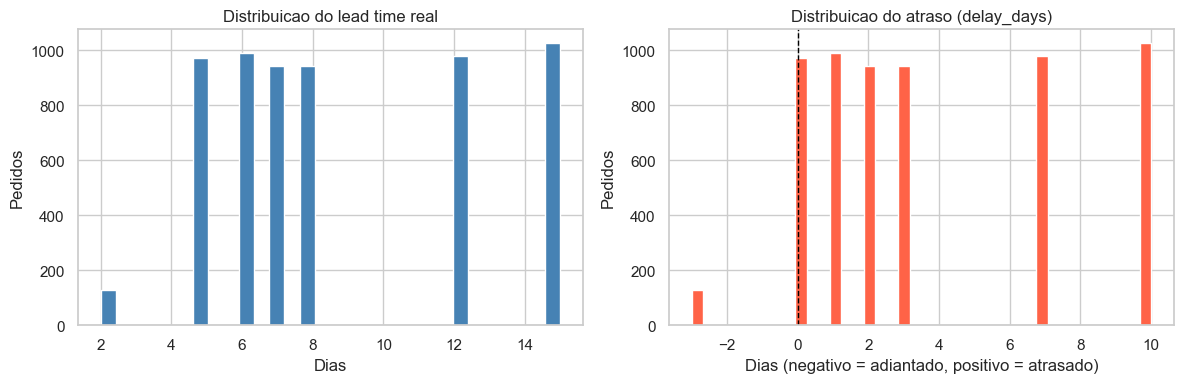

In [5]:
fig, eixos = plt.subplots(1, 2, figsize=(12, 4))

eixos[0].hist(pedidos['lead_time_days'], bins=30, color='steelblue', edgecolor='white')
eixos[0].set_title('Distribuicao do lead time real')
eixos[0].set_xlabel('Dias')
eixos[0].set_ylabel('Pedidos')

eixos[1].hist(pedidos['delay_days'], bins=40, color='tomato', edgecolor='white')
eixos[1].axvline(0, color='black', linestyle='--', linewidth=1)
eixos[1].set_title('Distribuicao do atraso (delay_days)')
eixos[1].set_xlabel('Dias (negativo = adiantado, positivo = atrasado)')
eixos[1].set_ylabel('Pedidos')

plt.tight_layout()
plt.show()

**Interpretacao:** A maioria dos pedidos cai a direita do zero, confirmando o OTIF baixo (~17%). O lead time apresenta distribuicao bimodal, sugerindo dois padroes de atendimento distintos na operacao.

## Colunas Derivadas — Producao

| Coluna | Calculo | Significado |
|---|---|---|
| `utilization_rate` | `produced_quantity / production_capacity` | Fracao da capacidade utilizada (> 1.0 = acima da capacidade) |
| `over_capacity` | `produced_quantity > production_capacity` | Flag de producao acima da capacidade declarada |

In [6]:
util_por_planta = conn.execute(f"""
    SELECT plant, product,
           ROUND(AVG(utilization_rate), 3) AS utilizacao_media,
           ROUND(100.0 * SUM(CASE WHEN over_capacity THEN 1 ELSE 0 END) / COUNT(*), 1) AS pct_acima
    FROM read_parquet('{SILVER}/production.parquet')
    GROUP BY plant, product
    ORDER BY plant, product
""").df()

print(util_por_planta.to_string(index=False))

  plant product  utilizacao_media  pct_acima
 P_APAC       A             0.755       19.7
 P_APAC       B             0.750       23.5
 P_APAC       C             0.748       23.1
   P_EU       A             0.755       23.0
   P_EU       B             0.738       20.2
   P_EU       C             0.748       22.4
P_LATAM       A             0.741       20.1
P_LATAM       B             0.749       22.8
P_LATAM       C             0.746       23.7
   P_NA       A             0.759       22.7
   P_NA       B             0.753       23.9
   P_NA       C             0.761       23.4


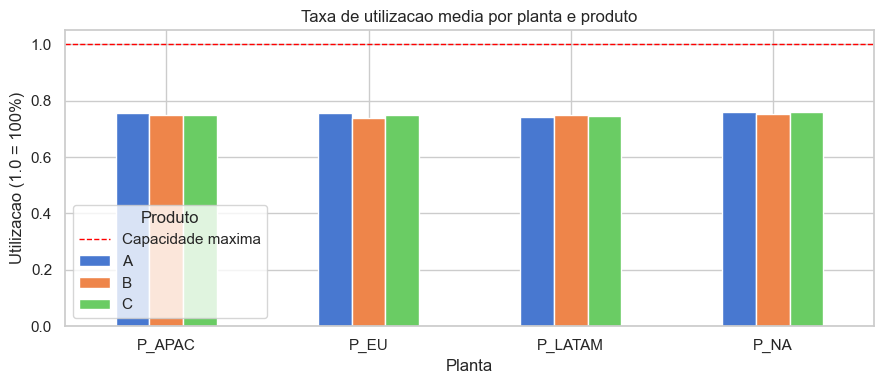

In [7]:
util_pivot = util_por_planta.pivot(index='plant', columns='product', values='utilizacao_media')

fig, ax = plt.subplots(figsize=(9, 4))
util_pivot.plot(kind='bar', ax=ax, edgecolor='white')
ax.axhline(1.0, color='red', linestyle='--', linewidth=1, label='Capacidade maxima')
ax.set_title('Taxa de utilizacao media por planta e produto')
ax.set_xlabel('Planta')
ax.set_ylabel('Utilizacao (1.0 = 100%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Produto')
plt.tight_layout()
plt.show()

## Colunas Derivadas — Estoque

| Coluna | Calculo | Significado |
|---|---|---|
| `stockout_flag` | `stock_level <= 0` | Dia com estoque zerado ou negativo (risco de ruptura) |
| `overflow_flag` | `stock_level > warehouse_capacity` | Dia com estoque acima da capacidade do armazem |
| `warehouse_utilization` | `stock_level / warehouse_capacity` | Fracao da capacidade do armazem ocupada |

In [8]:
resumo_inv = conn.execute(f"""
    SELECT
        SUM(CASE WHEN stockout_flag THEN 1 ELSE 0 END)  AS total_stockout,
        SUM(CASE WHEN overflow_flag THEN 1 ELSE 0 END)  AS total_overflow,
        ROUND(AVG(warehouse_utilization), 3)            AS utilizacao_media,
        COUNT(*)                                        AS total_registros
    FROM read_parquet('{SILVER}/inventory.parquet')
""").df()

print(resumo_inv.to_string(index=False))

 total_stockout  total_overflow  utilizacao_media  total_registros
          336.0          1301.0             0.565             8772


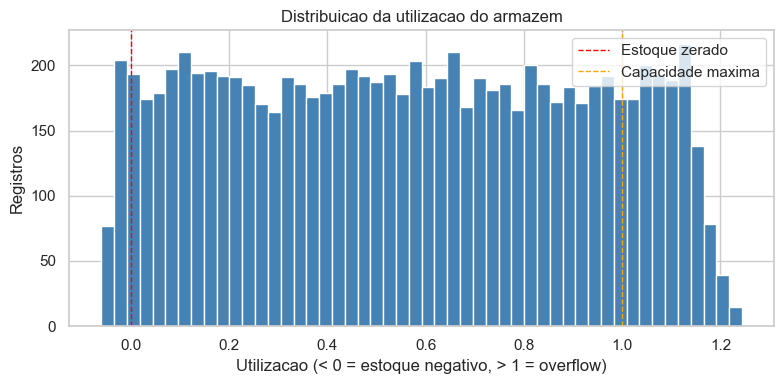

In [9]:
util_inv = conn.execute(f"""
    SELECT warehouse_utilization
    FROM read_parquet('{SILVER}/inventory.parquet')
    WHERE warehouse_utilization BETWEEN -0.5 AND 2.0
""").df()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(util_inv['warehouse_utilization'], bins=50, color='steelblue', edgecolor='white')
ax.axvline(0, color='red', linestyle='--', linewidth=1, label='Estoque zerado')
ax.axvline(1, color='orange', linestyle='--', linewidth=1, label='Capacidade maxima')
ax.set_title('Distribuicao da utilizacao do armazem')
ax.set_xlabel('Utilizacao (< 0 = estoque negativo, > 1 = overflow)')
ax.set_ylabel('Registros')
ax.legend()
plt.tight_layout()
plt.show()

## Resumo da Camada Silver

| Tabela | Colunas adicionadas | Deduplicacao |
|---|---|---|
| orders | lead_time_days, delay_days, on_time | DISTINCT (123 duplicatas identicas removidas) |
| production | utilization_rate, over_capacity | Por (date, region, product) |
| inventory | stockout_flag, overflow_flag, warehouse_utilization | Por (date, region, product) |

Os dados estao prontos para os calculos da camada gold: OTIF, metricas de estoque, utilizacao de producao e balanco oferta/demanda.

In [10]:
conn.close()